Accept as inputs a data file specifying two sets of points. The points are 2D ( thus on plane) and are also associated with a label +1 (color red) or a label -1 (color blue)

In [10]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Generate the data.
# We associate the data above the line y = 0.5x + 1 with the label +1, and the data below the line with the label -1. 
np.random.seed(42)
X = np.random.randn(100, 2)
y = np.sign(0.5 * X[:, 0] + 1 - X[:, 1]) 

w = cp.Variable(2)
b = cp.Variable()

constraints = [y[i] * (w.T @ X[i] + b) >= 1 for i in range(len(X))]
objective = cp.Minimize(cp.norm(w, 2))
problem = cp.Problem(objective, constraints)
problem.solve()

print("Optimal w:", w.value)
print("Optimal b:", b.value)

Optimal w: [ 38.70092765 -79.93863282]
Optimal b: 77.97047058857586


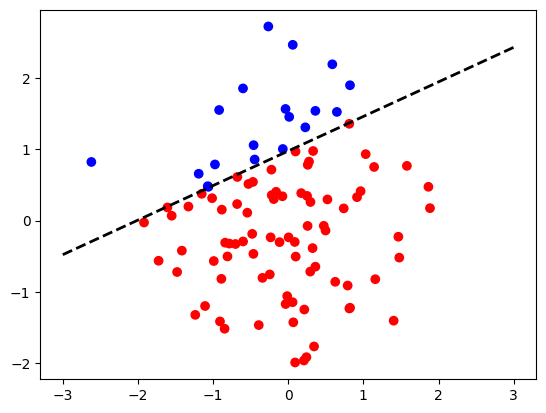

In [11]:
# plot the data and the decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
x_decision = np.linspace(-3, 3, 100)
y_decision = -w.value[0] / w.value[1] * x_decision - b.value / w.value[1]
plt.plot(x_decision, y_decision, 'k--', lw=2)